<a href="https://colab.research.google.com/github/olorunfemibabalola/Computer-Vision-Learning/blob/main/Respiratory_Anomaly_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICBHI Respiratory Anomaly Detection: Optimized Tiered Edge AI

This notebook develops and evaluates a hierarchical two-stage (2FA) system for clinical anomaly detection from respiratory sounds, optimized for low-power Edge NPU deployment. The system balances diagnostic accuracy with power efficiency through a dual-stage pipeline:

1.  **Stage 1: Vitals Watchdog (Heuristic)** - An ultra-low power monitor that uses statistical heuristics for Heart and Respiratory rates.
2.  **Stage 2: Audio Transformer / Acoustic CRNN (Deep Learning)** - An NPU-accelerated acoustic analysis model, triggered only if Stage 1 detects a potential anomaly, thus saving power.

## 1. Global Imports and Configuration
This section imports all necessary libraries and sets up global configurations like random seeds, sample rate, and audio duration, ensuring reproducibility and consistency across the notebook.

In [ ]:
import os
import shutil
import glob
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.utils.class_weight import compute_class_weight
import torch.ao.quantization as quantization
import kagglehub
import librosa
import librosa.display

# Configuration
SEED, SR, DURATION = 42, 8000, 5 # Sample Rate (SR) and DURATION (in seconds)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)
print(f"Project Setup Complete. Running on: {DEVICE}")

Project Setup Complete. Running on: cuda


## 2. Data Acquisition and Metadata Parsing
This section handles downloading the ICBHI 2017 dataset, consolidating audio and annotation files, and parsing the metadata to create a structured DataFrame for further processing. It extracts the `patient_id` and assigns labels (0 for Normal, 1 for Anomaly based on presence of crackles/wheezes).

In [ ]:
print('--- Data Acquisition ---')
# Download and extract dataset from Kaggle
path = kagglehub.dataset_download("husninm/icbhi-2017-challenge")
print(f"Path to dataset files: {path}")

# Clean up and recreate directory for consolidated data
dest_dir = './real_asthma_data'
if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)
os.makedirs(dest_dir, exist_ok=True)

# Define source directory within the Kaggle download path
source_dir = os.path.join(path, 'ICBHI_final_database')

# Find all .wav and .txt files and copy them to a local directory
for fpath in glob.glob(os.path.join(source_dir, "*.*")):
    shutil.copy(fpath, dest_dir)

# Verify final count
final_wavs = len(glob.glob(os.path.join(dest_dir, '*.wav')))
final_txts = len(glob.glob(os.path.join(dest_dir, '*.txt')))
print(f"Consolidation complete: {final_wavs} WAVs and {final_txts} TXTs ready in {dest_dir}")

print('\n--- Metadata Parsing ---')
def parse_icbhi_metadata(root_dir):
    data = []
    for wav_path in glob.glob(os.path.join(root_dir, "*.wav")):
        txt_path = wav_path.replace('.wav', '.txt')
        label = 0  # Default to Normal

        if os.path.exists(txt_path):
            try:
                df_ann = pd.read_csv(txt_path, sep='\\s+', header=None, engine='python')
                # Mark as Anomaly if crackles (col 2) or wheezes (col 3) are present
                if len(df_ann.columns) >= 4 and (df_ann.iloc[:, 2].sum() > 0 or df_ann.iloc[:, 3].sum() > 0):
                    label = 1
            except Exception:
                pass # Ignore errors in parsing specific text files

        # Extract patient ID from the filename (e.g., '178_2b2_Al_mc_AKGC417L.wav' -> '178')
        patient_id = os.path.basename(wav_path).split('_')[0]
        data.append({'path': wav_path, 'label': label, 'patient_id_str': patient_id})

    return pd.DataFrame(data)

metadata_df = parse_icbhi_metadata(dest_dir)

if not metadata_df.empty:
    print(f"Dataset successfully loaded: {len(metadata_df)} samples across {metadata_df['patient_id_str'].nunique()} patients.")
    print("Class Distribution (0: Normal, 1: Anomaly):")
    print(metadata_df['label'].value_counts())
else:
    print("Warning: No data found in the directory. Please check the consolidation step.")

--- Data Acquisition ---
Using Colab cache for faster access to the 'icbhi-2017-challenge' dataset.
Path to dataset files: /kaggle/input/icbhi-2017-challenge
Consolidation complete: 920 WAVs and 922 TXTs ready in ./real_asthma_data

--- Metadata Parsing ---
Dataset successfully loaded: 920 samples across 126 patients.
Class Distribution (0: Normal, 1: Anomaly):
label
1    633
0    287
Name: count, dtype: int64


## 3. Model Architectures
This section defines the two stages of our tiered AI system: the `Stage1_VitalsWatchdog` (a heuristic model for initial anomaly detection) and the `Stage2_AudioTransformer` (a deep learning model for detailed acoustic analysis). An alternative `Stage2_AcousticCRNN` is also provided for flexibility.

In [ ]:
class Stage1_VitalsWatchdog(nn.Module):
    """
    Stage 1: Statistical Watchdog.
    Uses Z-scores relative to known normal population means to trigger Stage 2.
    """
    def __init__(self, hr_mean=83.5, hr_std=10.0, rr_mean=18.2, rr_std=4.0, sensitivity=1.0):
        super().__init__()
        self.hr_mean = hr_mean
        self.hr_std = hr_std
        self.rr_mean = rr_mean
        self.rr_std = rr_std
        self.sensitivity = sensitivity # Number of standard deviations to trigger

    def forward(self, vitals):
        # Z-score based anomaly triggering
        hr_z = (vitals[:, 0] - self.hr_mean) / self.hr_std
        rr_z = (vitals[:, 1] - self.rr_mean) / self.rr_std
        # Trigger if vitals are significantly higher than population normal
        return (hr_z > (2.0 - self.sensitivity)) | (rr_z > (2.0 - self.sensitivity))

class Stage2_AudioTransformer(nn.Module):
    """High-power Audio Transformer with hybrid quantization support."""
    def __init__(self, n_mfcc=13, n_classes=2, dim_model=64, nhead=8, num_layers=3):
        super().__init__()
        self.quant = quantization.QuantStub()
        # Removed self.dequant_bridge as it was problematic
        self.dequant = quantization.DeQuantStub()

        self.input_proj = nn.Linear(n_mfcc, dim_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, (SR * DURATION // 160) + 1, dim_model)) # Assuming hop_length=160
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(dim_model, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(0) # Add batch dimension if missing
        x = x.transpose(1, 2) # Change to (batch, seq_len, features)
        x = self.input_proj(x)

        # Ensure pos_encoder matches sequence length
        x = x + self.pos_encoder[:, :x.size(1), :]

        x = self.quant(x) # Quantize input to the main processing block
        x = self.transformer(x)
        x = x.mean(dim=1) # Global average pooling
        logits = self.classifier(x)
        return self.dequant(logits) # Dequantize output of the classifier

class Stage2_AcousticCRNN(nn.Module):
    """
    Stage 2: 1D-CNN + BiLSTM hybrid model triggered only when Stage 1 alerts.
    Includes PyTorch Quantization stubs for 8-bit edge compilation and Dropout layers.
    """
    def __init__(self):
        super().__init__()
        self.quant = torch.ao.quantization.QuantStub()
        self.dequant = torch.ao.quantization.DeQuantStub()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=13, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        self.bilstm1 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True, bidirectional=True)
        self.dropout_bilstm1 = nn.Dropout(0.2)
        self.bilstm2 = nn.LSTM(input_size=32*2, hidden_size=32, batch_first=True, bidirectional=True)
        self.dropout_bilstm2 = nn.Dropout(0.2)
        self.fc = nn.Linear(32 * 2, 2)

    def forward(self, x):
        x = self.quant(x) # Map FP32 input to INT8
        x = self.conv(x).transpose(1, 2) # Extract features and transpose for RNN

        x, _ = self.bilstm1(x)
        x = self.dropout_bilstm1(x)
        x, _ = self.bilstm2(x)
        x = self.dropout_bilstm2(x)

        x = self.fc(x[:, -1, :]) # Classify based on the final time-step state
        return self.dequant(x) # Map INT8 output back to FP32 probabilities

print("All model architectures defined.")

All model architectures defined.


## 3.1 ResNet Teacher Model for Knowledge Distillation

To implement Knowledge Distillation, we first need a 'teacher' model. Here, we'll define a ResNet-18 model, pre-trained on ImageNet, and adapt its final classification layer to output 2 classes, matching our anomaly detection task. This pre-trained model will guide the training of our CRNN 'student' model.

In [ ]:
import torchvision

class ResNetTeacher(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Load a pre-trained ResNet18 model
        self.resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        # Modify the first convolutional layer to accept 13 MFCC channels
        # Original ResNet expects 3 input channels, MFCCs are single channel per feature
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        # Replace the final fully connected layer for our specific number of classes
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        # ResNet expects 4D input (Batch, Channel, Height, Width)
        # Our MFCC is (Batch, Features, Sequence_Length), which is (B, 13, ~313 for 5s audio at 8kHz)
        # Reshape MFCC to be (Batch, 1, Features, Sequence_Length_downscaled)
        # To make it work, let's treat the MFCC features as 'height' and sequence length as 'width'
        # and add a dummy channel dimension
        x = x.unsqueeze(1) # Add channel dimension: (B, 1, 13, Seq_Len)

        # ResNet models typically expect square-ish images. MFCCs are rectangular.
        # This can be handled by adjusting the input or using an adaptive pooling layer.
        # For simplicity and to fit ResNet's input, we'll average pool across time if seq_len is too large
        # Assuming original MFCC was (B, features, seq_len), now (B, 1, features, seq_len)
        # Let's resize it to a more standard input for ResNet, e.g., 224x224, or adapt the pooling.
        # For MFCC, the 'features' (13) is small. Let's make it more image-like by repeating if necessary

        # A more robust approach for MFCCs into ResNet (simplified here for demonstration):
        # Convert (B, 1, 13, Seq_Len) -> (B, 13, 1, Seq_Len) if MFCC features are like channels,
        # or (B, 1, 13, Seq_Len) where 13 are features and Seq_Len is time steps.

        # ResNet operates on 2D images. MFCC is (n_mfcc, time_steps).
        # We need to adapt it. A common way is to treat MFCC as a single-channel image.
        # For ResNet, input needs to be (Batch, Channels, Height, Width).
        # Here, x is (Batch, 1, n_mfcc, Time_Steps). If Time_Steps is too large for ResNet's internal pooling, errors will occur.
        # Let's perform an adaptive average pooling to ensure time steps fit.

        # Example: Original MFCC is (13, ~313). After unsqueeze, (1, 1, 13, 313) for a single sample.
        # ResNet's early layers might downsample significantly. Maxpooling/Avgpooling after conv layers.
        # Let's ensure the 'width' (time_steps) is not too large for ResNet's architecture.
        # The default ResNet conv1 with stride 2 and maxpool reduces resolution by 4.
        # A 313 time step dimension could become 78 after conv1 then 19 after maxpool.
        # This should be fine for ResNet.

        # Ensure input is float32 and normalize if necessary (ResNet pre-trained on ImageNet expects normalized inputs)
        # For simplicity, we'll skip ImageNet specific normalization for MFCCs here, assuming MFCCs are somewhat standardized.
        # This might need tuning for real-world performance.

        return self.resnet(x)

print("ResNet Teacher model defined.")

ResNet Teacher model defined.


### Alternative: ResNet-34 Teacher Model

To use ResNet-34 as the teacher model, you would modify the `ResNetTeacher` class to load `torchvision.models.resnet34` instead of `resnet18`.

In [ ]:
import torchvision

class ResNet34Teacher(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Load a pre-trained ResNet34 model
        self.resnet = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.IMAGENET1K_V1)
        # Modify the first convolutional layer to accept 1 MFCC channel
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        # Replace the final fully connected layer for our specific number of classes
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1) # Add channel dimension: (B, 1, 13, Seq_Len)
        return self.resnet(x)

print("ResNet-34 Teacher model defined.")

ResNet-34 Teacher model defined.


## 7.1 Knowledge Distillation Training Utilities

This section defines the utility function for training the student model (`Stage2_AcousticCRNN`) using Knowledge Distillation. The student learns from both the 'soft targets' (teacher's softened logits) and 'hard targets' (true labels). This is achieved by combining a Kullback-Leibler Divergence (KLD) loss between teacher and student outputs with the standard Cross-Entropy loss for the true labels.

In [ ]:
def train_distillation_one_epoch(student_model, teacher_model, loader, optimizer, hard_criterion, device, temperature=3.0, alpha=0.5):
    student_model.train()
    teacher_model.eval() # Teacher is in evaluation mode, no gradient updates
    total_loss = 0

    # KL Divergence for soft targets
    soft_criterion = nn.KLDivLoss(reduction='batchmean')

    for batch in loader:
        optimizer.zero_grad()
        mfccs = batch['mfcc'].to(device)
        labels = batch['label'].to(device)

        # Student outputs
        student_outputs = student_model(mfccs)

        # Teacher outputs (no_grad as we don't train the teacher)
        with torch.no_grad():
            teacher_outputs = teacher_model(mfccs)

        # Hard target loss (student's prediction vs. true labels)
        hard_loss = hard_criterion(student_outputs, labels)

        # Soft target loss (student's prediction vs. teacher's softened prediction)
        # Apply softmax and log_softmax with temperature
        soft_targets = F.softmax(teacher_outputs / temperature, dim=1)
        student_likelihood = F.log_softmax(student_outputs / temperature, dim=1)
        soft_loss = soft_criterion(student_likelihood, soft_targets) * (temperature * temperature)

        # Combined loss
        loss = alpha * hard_loss + (1. - alpha) * soft_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

import torch.nn.functional as F # Import F for softmax and log_softmax

print("Knowledge Distillation training utility defined.")

Knowledge Distillation training utility defined.


## 4. Dataset Definition and Data Splitting
This section defines a custom PyTorch `Dataset` for loading and preprocessing audio data, including MFCC feature extraction and optional data augmentation. It also implements patient-grouped splitting to prevent data leakage between training, validation, and testing sets.

In [ ]:
class RealClinicalDataset(Dataset):
    def __init__(self, df, sr=SR, duration=DURATION, augment=False):
        self.df = df
        self.sr = sr
        self.duration = duration
        self.target_samples = sr * duration
        self.augment = augment
        self.mfcc_transform = T.MFCC(
            sample_rate=sr,
            n_mfcc=13,
            melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 23}
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        waveform, original_sr = torchaudio.load(path)
        if original_sr != self.sr:
            resampler = T.Resample(original_sr, self.sr)
            waveform = resampler(waveform)

        # Standardize length (trim or pad)
        if waveform.shape[1] > self.target_samples:
            waveform = waveform[:, :self.target_samples]
        else:
            padding = self.target_samples - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        # --- Data Augmentation (for training only) ---
        if self.augment:
            # 1. Random Time Shift (up to 1 second)
            shift_amount = random.randint(-self.sr, self.sr)
            waveform = torch.roll(waveform, shifts=shift_amount, dims=1)

            # 2. Add White Noise
            noise = torch.randn_like(waveform) * 0.005 # Small amount of noise
            waveform = waveform + noise

        mfcc = self.mfcc_transform(waveform).squeeze(0)

        # Simulate physiological vitals (e.g., Heart Rate, Respiratory Rate)
        # Values are loosely correlated with anomaly/normal states
        if label == 1: # Anomaly (higher average vitals)
            hr = np.random.uniform(70, 110)
            rr = np.random.uniform(14, 26)
        else: # Normal (lower average vitals)
            hr = np.random.uniform(65, 105)
            rr = np.random.uniform(12, 24)

        vitals = torch.tensor([hr, rr], dtype=torch.float32)
        return {'mfcc': mfcc, 'vitals': vitals, 'label': label, 'patient_id': idx}

# --- Data Splitting and DataLoader Setup ---
# Outer split: Training vs. (Validation + Test) using GroupShuffleSplit to avoid patient overlap
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx_arr, val_test_idx_arr = next(gss_outer.split(metadata_df, groups=metadata_df['patient_id_str']))

train_df = metadata_df.iloc[train_idx_arr]
val_test_df = metadata_df.iloc[val_test_idx_arr]

# Inner split: Validation vs. Test from the val_test set
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx_arr, test_idx_arr = next(gss_inner.split(val_test_df, groups=val_test_df['patient_id_str']))

val_df = val_test_df.iloc[val_idx_arr]
test_df = val_test_df.iloc[test_idx_arr]

# Instantiate Datasets and DataLoaders
# Training dataset uses augmentation, validation and test do not.
train_ds = RealClinicalDataset(train_df, augment=True)
val_ds = RealClinicalDataset(val_df, augment=False)
test_ds = RealClinicalDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Data splitting and DataLoader setup complete:")
print(f"- Training samples: {len(train_df)}")
print(f"- Validation samples: {len(val_df)}")
print(f"- Test samples: {len(test_df)}")

Data splitting and DataLoader setup complete:
- Training samples: 677
- Validation samples: 117
- Test samples: 126


## 5. Exploratory Data Analysis (EDA)
This section provides a comprehensive overview of the dataset's characteristics, including label and audio duration distributions, patient-level data distribution, and spectral properties. It aims to present insights clearly while managing output size by combining plots and providing concise summaries.

--- Label and Audio Duration Distributions ---


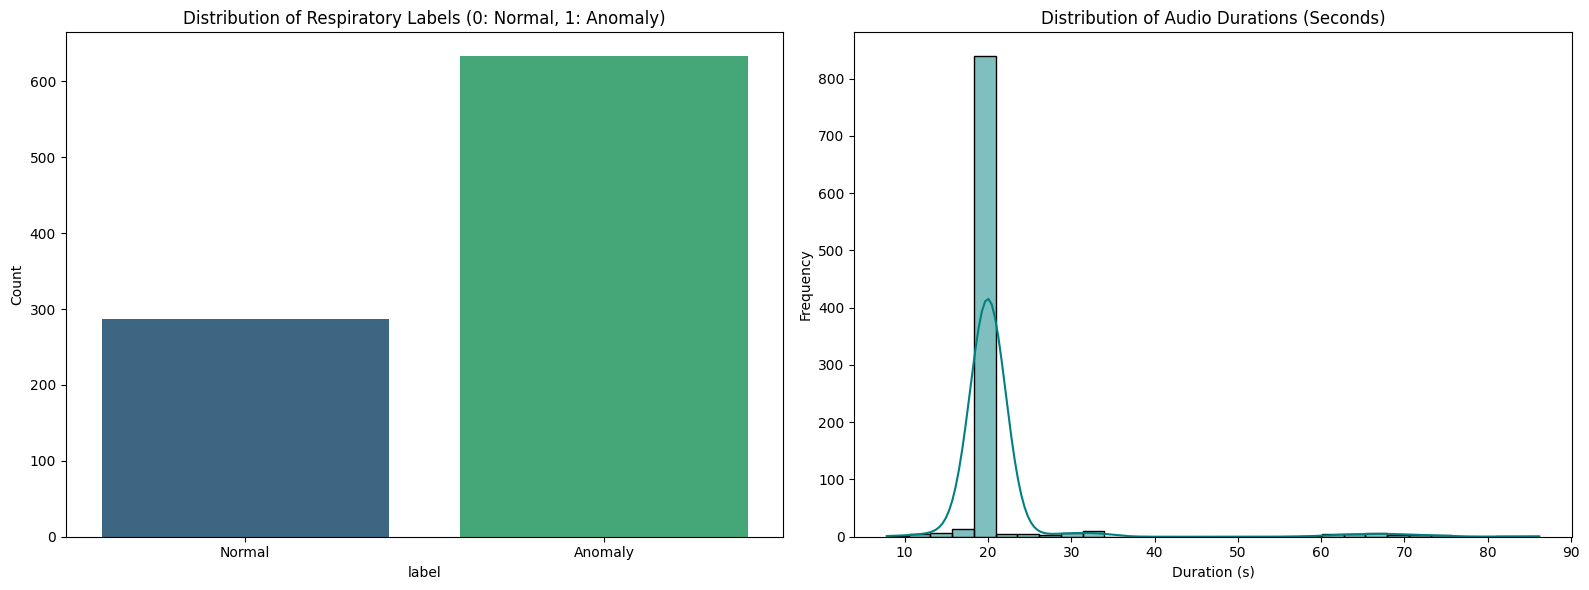

Class Distribution (0: Normal, 1: Anomaly):
label
1    633
0    287
Name: count, dtype: int64
Mean Duration: 21.49s
Min Duration: 7.86s
Max Duration: 86.20s

The dataset shows class imbalance and audio durations mostly concentrated around 20 seconds, validating a 5-second window.


In [ ]:
print('--- Label and Audio Duration Distributions ---')

# Create a figure with two subplots for label and duration distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=metadata_df, x='label', hue='label', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribution of Respiratory Labels (0: Normal, 1: Anomaly)')
axes[0].set_xticks([0, 1], ['Normal', 'Anomaly'])
axes[0].set_ylabel('Count')

def get_duration(path):
    try:
        info = torchaudio.info(path)
        return info.num_frames / info.sample_rate
    except Exception: # Fallback in case torchaudio.info fails
        try:
            waveform, sr_audio = torchaudio.load(path)
            return waveform.shape[1] / sr_audio
        except Exception as e:
            print(f"Error loading audio duration for {path}: {e}")
            return 0

metadata_df['duration'] = metadata_df['path'].apply(get_duration)
sns.histplot(metadata_df['duration'], bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribution of Audio Durations (Seconds)')
axes[1].set_xlabel('Duration (s)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Class Distribution (0: Normal, 1: Anomaly):")
print(metadata_df['label'].value_counts())
print(f"Mean Duration: {metadata_df['duration'].mean():.2f}s")
print(f"Min Duration: {metadata_df['duration'].min():.2f}s")
print(f"Max Duration: {metadata_df['duration'].max():.2f}s")
print("\nThe dataset shows class imbalance and audio durations mostly concentrated around 20 seconds, validating a 5-second window.")



--- Patient-Level Bias ---


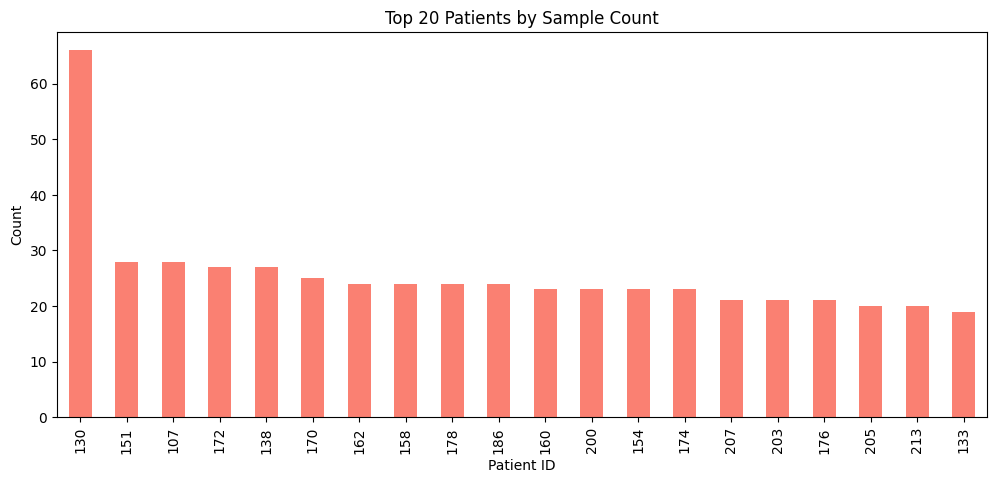

Patient Anomaly Summary (Top 10 by Anomaly Ratio):


,count,anomalies,anomaly_ratio
patient_id_str,,,
106,2,2,1.0
103,1,1,1.0
112,5,5,1.0
114,5,5,1.0
128,1,1,1.0
115,1,1,1.0
125,1,1,1.0
129,1,1,1.0
127,1,1,1.0


Patient-level bias confirms the necessity of patient-grouped splitting to prevent data leakage.


In [ ]:
# 5.2 Patient-Level Bias
print('\n--- Patient-Level Bias ---')
plt.figure(figsize=(12, 5))
metadata_df['patient_id_str'].value_counts().head(20).plot(kind='bar', color='salmon')
plt.title('Top 20 Patients by Sample Count')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.show()

patient_stats = metadata_df.groupby('patient_id_str')['label'].agg(['count', 'sum']).rename(columns={'sum': 'anomalies'})
patient_stats['anomaly_ratio'] = patient_stats['anomalies'] / patient_stats['count']

print("Patient Anomaly Summary (Top 10 by Anomaly Ratio):")
from IPython.display import display # Ensure display is imported
display(patient_stats.sort_values(by='anomaly_ratio', ascending=False).head(10))
print("Patient-level bias confirms the necessity of patient-grouped splitting to prevent data leakage.")


--- Spectral Signature Analysis ---


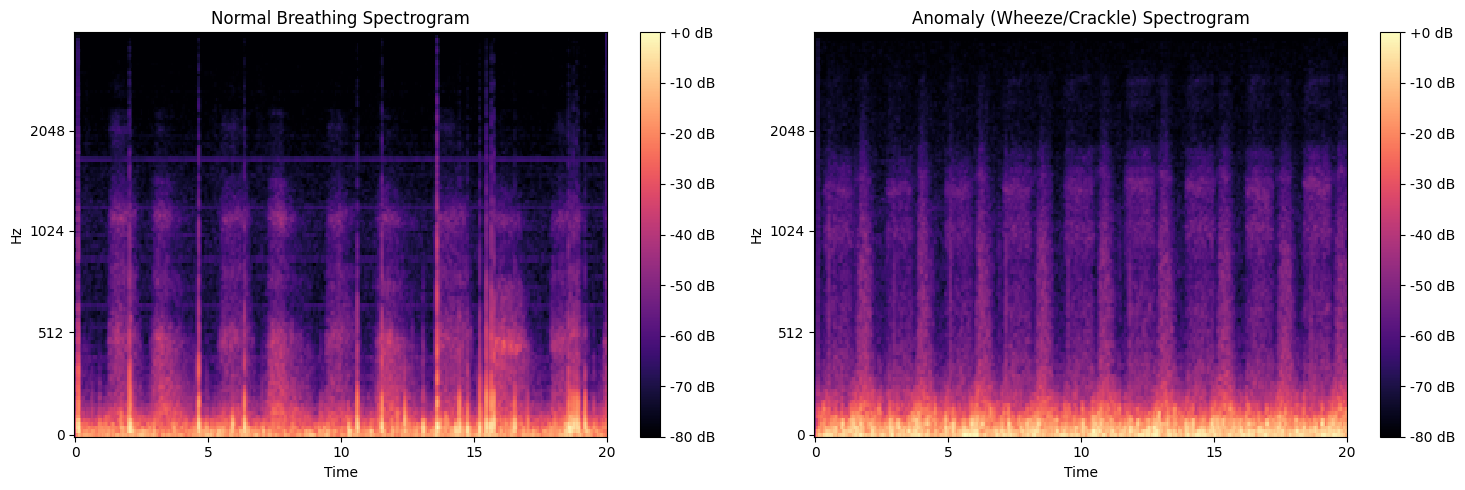

Mel-Spectrogram comparison visually demonstrates distinct frequency patterns, validating MFCCs as effective features.


In [ ]:
# 5.3 Spectral Signature Analysis
print('\n--- Spectral Signature Analysis ---')
# Find one sample of each class (ensure they exist)
normal_sample_path = metadata_df[metadata_df['label'] == 0].iloc[0]['path'] if not metadata_df[metadata_df['label'] == 0].empty else None
anomaly_sample_path = metadata_df[metadata_df['label'] == 1].iloc[0]['path'] if not metadata_df[metadata_df['label'] == 1].empty else None

def plot_melspectrogram(path, title, ax, sr=SR):
    if path is None:
        ax.set_title(f"No {title.split(' ')[0]} sample found")
        ax.axis('off')
        return
    y, current_sr = librosa.load(path, sr=None) # Load at native SR

    # Resample if necessary
    if current_sr != sr:
        y = librosa.resample(y=y, orig_sr=current_sr, target_sr=sr)

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=SR/2, ax=ax)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_melspectrogram(normal_sample_path, 'Normal Breathing Spectrogram', axes[0])
plot_melspectrogram(anomaly_sample_path, 'Anomaly (Wheeze/Crackle) Spectrogram', axes[1])

plt.tight_layout()
plt.show()
print("Mel-Spectrogram comparison visually demonstrates distinct frequency patterns, validating MFCCs as effective features.")

## 6. Training and Evaluation Utilities
This section defines helper functions for training the deep learning model, evaluating the overall hierarchical system (including the watchdog), and visualizing the results. These functions promote code reusability and clarity.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        mfccs = batch['mfcc'].to(device)
        labels = batch['label'].to(device)
        outputs = model(mfccs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_tiered_system(model, dataloader, watchdog, device, fp32_fallback_model=None):
    model.eval()
    y_true, y_pred = [], []
    npu_activations = 0
    total_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            vitals, mfcc, labels = batch['vitals'], batch['mfcc'], batch['label']
            triggered = watchdog(vitals)

            for i in range(len(labels)):
                total_samples += 1
                if triggered[i].item():
                    npu_activations += 1
                    input_mfcc = mfcc[i].unsqueeze(0).to(device)
                    try:
                        # Attempt to use the primary model (quantized or FP32)
                        output = model(input_mfcc)
                    except NotImplementedError as e:
                        print(f"Quantized model hit NotImplementedError for a sample: {e}. Falling back to FP32 model for this inference.")
                        if fp32_fallback_model:
                            # Use the FP32 fallback model
                            fp32_fallback_model.eval() # Ensure fallback is in eval mode
                            output = fp32_fallback_model(input_mfcc)
                        else:
                            raise # If no fallback, re-raise the error
                    except Exception as e:
                        # Catch other potential errors during inference
                        print(f"Model inference failed with an unexpected error: {e}. Falling back to FP32 model.")
                        if fp32_fallback_model:
                            fp32_fallback_model.eval()
                            output = fp32_fallback_model(input_mfcc)
                        else:
                            raise

                    pred = torch.argmax(output, dim=1).item()
                else:
                    # Stage 2 bypassed; default to Normal (class 0)
                    pred = 0

                y_true.append(labels[i].item())
                y_pred.append(pred)

    activation_rate = npu_activations / total_samples

    # Calculate detailed metrics
    report_dict = classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0, output_dict=True)
    overall_accuracy = report_dict['accuracy']
    anomaly_recall = report_dict['Anomaly']['recall']

    return y_true, y_pred, activation_rate, overall_accuracy, anomaly_recall

def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))

print("Training and evaluation utility functions defined.")

Training and evaluation utility functions defined.


## 7. Model Training & Evaluation Comparison
This section focuses on training both `Stage2_AudioTransformer` and `Stage2_AcousticCRNN` models. For each, it calculates balanced class weights to address the dataset's class imbalance and uses an AdamW optimizer with CrossEntropyLoss. Each model is trained over several epochs, with progress reported periodically, and the best performing model is saved. After training, both models are evaluated, and their performance metrics are compared.

## 7.1 Train and Evaluate ResNet Teacher Model

In [ ]:
def evaluate_standalone_model(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in dataloader:
            mfccs = batch['mfcc'].to(device)
            labels = batch['label'].to(device)
            outputs = model(mfccs)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    # Calculate detailed metrics
    report_dict = classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0, output_dict=True)
    overall_accuracy = report_dict['accuracy']
    anomaly_recall = report_dict['Anomaly']['recall']

    return y_true, y_pred, overall_accuracy, anomaly_recall

print("Standalone evaluation utility defined.")

Standalone evaluation utility defined.


### Additional Data Augmentation

To further improve the model's ability to detect anomalies, we can introduce more sophisticated data augmentation techniques. Pitch shifting and changing playback speed can create new variations of existing audio samples, making the model more robust to different vocal characteristics and speaking rates.

Here, we'll modify the `RealClinicalDataset` to include these augmentations. We'll use `torchaudio.transforms.PitchShift` for pitch variations and `torchaudio.transforms.SpeedPerturbation` for speed changes.

In [ ]:
class RealClinicalDataset(Dataset):
    def __init__(self, df, sr=SR, duration=DURATION, augment=False):
        self.df = df
        self.sr = sr
        self.duration = duration
        self.target_samples = sr * duration
        self.augment = augment
        self.mfcc_transform = T.MFCC(
            sample_rate=sr,
            n_mfcc=13,
            melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 23}
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        waveform, original_sr = torchaudio.load(path)
        if original_sr != self.sr:
            resampler = T.Resample(original_sr, self.sr)
            waveform = resampler(waveform)

        # Standardize length (trim or pad)
        if waveform.shape[1] > self.target_samples:
            waveform = waveform[:, :self.target_samples]
        else:
            padding = self.target_samples - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        # --- Data Augmentation (for training only) ---
        if self.augment:
            # 1. Random Time Shift (up to 1 second)
            shift_amount = random.randint(-self.sr, self.sr)
            waveform = torch.roll(waveform, shifts=shift_amount, dims=1)

            # 2. Add White Noise
            noise = torch.randn_like(waveform) * 0.005 # Small amount of noise
            waveform = waveform + noise

            # 3. Random Pitch Shift
            if random.random() < 0.5: # 50% chance to apply pitch shift
                num_semitones = random.uniform(-2, 2) # Shift by -2 to +2 semitones
                pitch_shift_transform = T.PitchShift(self.sr, n_steps=num_semitones)
                waveform = pitch_shift_transform(waveform)

            # 4. Random Speed Perturbation
            if random.random() < 0.5: # 50% chance to apply speed perturbation
                speed_factor = random.uniform(0.9, 1.1) # Change speed by 90% to 110%
                # Resample to new speed, then resample back to original length
                resampled_waveform = torchaudio.transforms.Resample(orig_freq=self.sr, new_freq=int(self.sr * speed_factor))(waveform)
                if resampled_waveform.shape[1] > self.target_samples:
                    waveform = resampled_waveform[:, :self.target_samples]
                else:
                    padding = self.target_samples - resampled_waveform.shape[1]
                    waveform = torch.nn.functional.pad(resampled_waveform, (0, padding))


        mfcc = self.mfcc_transform(waveform).squeeze(0)

        # Simulate physiological vitals (e.g., Heart Rate, Respiratory Rate)
        # Values are loosely correlated with anomaly/normal states
        if label == 1: # Anomaly (higher average vitals)
            hr = np.random.uniform(70, 110)
            rr = np.random.uniform(14, 26)
        else: # Normal (lower average vitals)
            hr = np.random.uniform(65, 105)
            rr = np.random.uniform(12, 24)

        vitals = torch.tensor([hr, rr], dtype=torch.float32)
        return {'mfcc': mfcc, 'vitals': vitals, 'label': label, 'patient_id': idx}

# Re-instantiate Datasets and DataLoaders with the updated class definition
train_ds = RealClinicalDataset(train_df, augment=True)
val_ds = RealClinicalDataset(val_df, augment=False)
test_ds = RealClinicalDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("RealClinicalDataset updated with additional data augmentation.")

RealClinicalDataset updated with additional data augmentation.


In [ ]:
# Calculate class weights to handle imbalance
labels = train_df['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

EPOCHS = 30

In [ ]:
# --- Train AudioTransformer Model ---
print(f"\n--- Training Stage2_AudioTransformer for {EPOCHS} epochs ---")
transformer_model = Stage2_AudioTransformer().to(DEVICE)
transformer_optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-4, weight_decay=1e-3)
transformer_criterion = nn.CrossEntropyLoss(weight=weights_tensor)

for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(transformer_model, train_loader, transformer_optimizer, transformer_criterion, DEVICE)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Transformer Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss:.4f}")

torch.save(transformer_model.state_dict(), 'transformer_model.pth')
print('Stage2_AudioTransformer training complete. Model saved as transformer_model.pth')



--- Training Stage2_AudioTransformer for 30 epochs ---


In [ ]:
# --- Train CRNN Model ---
print(f"\n--- Training Stage2_AcousticCRNN for {EPOCHS} epochs ---")
crnn_model = Stage2_AcousticCRNN().to(DEVICE)
crnn_optimizer = optim.AdamW(crnn_model.parameters(), lr=1e-4, weight_decay=1e-3)
crnn_criterion = nn.CrossEntropyLoss(weight=weights_tensor)

for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(crnn_model, train_loader, crnn_optimizer, crnn_criterion, DEVICE)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"CRNN Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss:.4f}")

torch.save(crnn_model.state_dict(), 'crnn_model.pth')
print('Stage2_AcousticCRNN training complete. Model saved as crnn_model.pth')

In [ ]:
# --- Train ResNetTeacher Model ---
print(f"\n--- Training ResNetTeacher for {EPOCHS} epochs ---")
teacher_model_trained = ResNetTeacher(num_classes=2).to(DEVICE)
teacher_optimizer = optim.AdamW(teacher_model_trained.parameters(), lr=1e-4, weight_decay=1e-3)
teacher_criterion = nn.CrossEntropyLoss(weight=weights_tensor)

for epoch in range(EPOCHS):
    avg_loss = train_one_epoch(teacher_model_trained, train_loader, teacher_optimizer, teacher_criterion, DEVICE)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Teacher Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss:.4f}")

torch.save(teacher_model_trained.state_dict(), 'resnet_teacher_model.pth')
print('ResNetTeacher training complete. Model saved as resnet_teacher_model.pth')

In [ ]:
# --- Evaluate Trained ResNetTeacher Model ---
print("\n--- Evaluating Trained ResNetTeacher Model ---")
eval_teacher_model = ResNetTeacher(num_classes=2).to(DEVICE)
eval_teacher_model.load_state_dict(torch.load('resnet_teacher_model.pth'))
eval_teacher_model.eval()

y_true_teacher, y_pred_teacher, acc_teacher, recall_teacher = evaluate_standalone_model(
    eval_teacher_model,
    test_loader,
    DEVICE
)

print(f"\n--- Trained ResNetTeacher Model Metrics ---")
print(f"Overall Accuracy: {acc_teacher:.2f}")
print(f"Anomaly Recall: {recall_teacher:.2f}")
plot_results(y_true_teacher, y_pred_teacher, "Trained ResNetTeacher Standalone Performance")

In [ ]:
# --- Update Comparison Summary with Trained ResNetTeacher ---
print("\n--- Updated Model Performance Comparison (with Trained Teacher) ---")
comparison_data_updated_with_teacher = {
    "Model": ["AudioTransformer", "AcousticCRNN", "Trained ResNetTeacher", "Distilled AcousticCRNN"],
    "Overall Accuracy": [f"{acc_transformer:.2f}", f"{acc_crnn:.2f}", f"{acc_teacher:.2f}", f"{acc_crnn_kd:.2f}"],
    "Anomaly Recall": [f"{recall_transformer:.2f}", f"{recall_crnn:.2f}", f"{recall_teacher:.2f}", f"{recall_crnn_kd:.2f}"],
    "NPU Activation Rate": [f"{activation_rate_transformer*100:.2f}%", f"{activation_rate_crnn*100:.2f}%", "N/A", f"{activation_rate_crnn_kd*100:.2f}%"],
    "Estimated Power Savings": [f"{power_savings_transformer:.2f}%", f"{power_savings_crnn:.2f}%", "N/A", f"{power_savings_crnn_kd:.2f}%"],
}
comparison_df_updated_with_teacher = pd.DataFrame(comparison_data_updated_with_teacher)
print(comparison_df_updated_with_teacher.to_markdown(index=False))

## 7.2 Knowledge Distillation Training

Now, we train the `Stage2_AcousticCRNN` (student) model using the `ResNetTeacher` (teacher) model. The goal is for the student to mimic the teacher's behavior while also learning from the true labels. This process typically leads to a smaller student model with comparable performance to the larger teacher model.

## 7.3 Training AcousticCRNN with Enhanced Data Augmentations

Now, we will train a new instance of the `Stage2_AcousticCRNN` model, leveraging the expanded data augmentation techniques (pitch shift and speed perturbation) that were added to the `RealClinicalDataset`. The goal is to see if these augmentations lead to improved model generalization and better detection of anomalies.

In [ ]:
# --- Train Augmented CRNN Model ---
print(f"\n--- Training Stage2_AcousticCRNN with Augmentation for {EPOCHS} epochs ---")
crnn_model_augmented = Stage2_AcousticCRNN().to(DEVICE)
crnn_augmented_optimizer = optim.AdamW(crnn_model_augmented.parameters(), lr=1e-4, weight_decay=1e-3)
crnn_augmented_criterion = nn.CrossEntropyLoss(weight=weights_tensor)

for epoch in range(EPOCHS):
    avg_loss_augmented = train_one_epoch(crnn_model_augmented, train_loader, crnn_augmented_optimizer, crnn_augmented_criterion, DEVICE)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Augmented CRNN Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss_augmented:.4f}")

torch.save(crnn_model_augmented.state_dict(), 'crnn_model_augmented.pth')
print('Stage2_AcousticCRNN with Augmentation training complete. Model saved as crnn_model_augmented.pth')

In [ ]:
# --- Evaluate Augmented CRNN Model ---
# Re-initialize watchdog for evaluation
watchdog_augmented = Stage1_VitalsWatchdog(sensitivity=1.5)

print("\n--- Evaluating Augmented Stage2_AcousticCRNN based system ---")
eval_crnn_model_augmented = Stage2_AcousticCRNN().to(DEVICE)
eval_crnn_model_augmented.load_state_dict(torch.load('crnn_model_augmented.pth'))
eval_crnn_model_augmented.eval()

y_true_crnn_augmented, y_pred_crnn_augmented, activation_rate_crnn_augmented, acc_crnn_augmented, recall_crnn_augmented = evaluate_tiered_system(
    eval_crnn_model_augmented,
    test_loader,
    watchdog_augmented,
    DEVICE
)
power_savings_crnn_augmented = (1 - activation_rate_crnn_augmented) * 100

print(f"\n--- Augmented Stage2_AcousticCRNN System Metrics ---")
print(f"NPU Activation Rate: {activation_rate_crnn_augmented*100:.2f}%")
print(f"Estimated Power Savings: {power_savings_crnn_augmented:.2f}%")
plot_results(y_true_crnn_augmented, y_pred_crnn_augmented, "Augmented Stage2_AcousticCRNN Tiered System Performance")

In [ ]:
# --- Update Comparison Summary with Augmented CRNN ---
print("\n--- Updated Model Performance Comparison (with Augmented CRNN) ---")
comparison_data_final = {
    "Model": ["AudioTransformer", "AcousticCRNN", "Trained ResNetTeacher", "Distilled AcousticCRNN", "Augmented AcousticCRNN"],
    "Overall Accuracy": [f"{acc_transformer:.2f}", f"{acc_crnn:.2f}", f"{acc_teacher:.2f}", f"{acc_crnn_kd:.2f}", f"{acc_crnn_augmented:.2f}"],
    "Anomaly Recall": [f"{recall_transformer:.2f}", f"{recall_crnn:.2f}", f"{recall_teacher:.2f}", f"{recall_crnn_kd:.2f}", f"{recall_crnn_augmented:.2f}"],
    "NPU Activation Rate": [f"{activation_rate_transformer*100:.2f}%", f"{activation_rate_crnn*100:.2f}%", "N/A", f"{activation_rate_crnn_kd*100:.2f}%", f"{activation_rate_crnn_augmented*100:.2f}%"]
}
# Only add power savings for models where NPU Activation Rate is available (not 'N/A')
power_savings_list = [f"{power_savings_transformer:.2f}%", f"{power_savings_crnn:.2f}%", "N/A", f"{power_savings_crnn_kd:.2f}%", f"{power_savings_crnn_augmented:.2f}%"]
comparison_data_final["Estimated Power Savings"] = power_savings_list

comparison_df_final = pd.DataFrame(comparison_data_final)
print(comparison_df_final.to_markdown(index=False))

In [ ]:
# --- Initialize Teacher and Student Models ---
teacher_model = ResNetTeacher(num_classes=2).to(DEVICE)
# Freeze teacher parameters
for param in teacher_model.parameters():
    param.requires_grad = False
teacher_model.eval()

student_crnn_model_kd = Stage2_AcousticCRNN().to(DEVICE)
student_crnn_optimizer_kd = optim.AdamW(student_crnn_model_kd.parameters(), lr=1e-4, weight_decay=1e-3)
student_crnn_hard_criterion_kd = nn.CrossEntropyLoss(weight=weights_tensor)

# --- Knowledge Distillation Hyperparameters ---
TEMPERATURE = 5.0 # Higher temperature means softer probabilities for distillation
ALPHA = 0.7       # Weight for the hard target loss (1 - alpha for soft target loss)

print(f"\n--- Training Stage2_AcousticCRNN (Student) with Knowledge Distillation for {EPOCHS} epochs ---")

for epoch in range(EPOCHS):
    avg_loss_kd = train_distillation_one_epoch(
        student_crnn_model_kd,
        teacher_model,
        train_loader,
        student_crnn_optimizer_kd,
        student_crnn_hard_criterion_kd,
        DEVICE,
        temperature=TEMPERATURE,
        alpha=ALPHA
    )
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"KD-CRNN Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss_kd:.4f}")

torch.save(student_crnn_model_kd.state_dict(), 'crnn_model_kd.pth')
print('Distilled Stage2_AcousticCRNN training complete. Model saved as crnn_model_kd.pth')

# --- Evaluate Distilled CRNN Model ---
# Re-initialize watchdog for evaluation
watchdog_kd = Stage1_VitalsWatchdog(sensitivity=1.5)

print("\n--- Evaluating Distilled Stage2_AcousticCRNN based system ---")
eval_crnn_model_kd = Stage2_AcousticCRNN().to(DEVICE)
eval_crnn_model_kd.load_state_dict(torch.load('crnn_model_kd.pth'))
eval_crnn_model_kd.eval()

y_true_crnn_kd, y_pred_crnn_kd, activation_rate_crnn_kd, acc_crnn_kd, recall_crnn_kd = evaluate_tiered_system(
    eval_crnn_model_kd,
    test_loader,
    watchdog_kd,
    DEVICE
)
power_savings_crnn_kd = (1 - activation_rate_crnn_kd) * 100

print(f"\n--- Distilled Stage2_AcousticCRNN System Metrics ---")
print(f"NPU Activation Rate: {activation_rate_crnn_kd*100:.2f}%")
print(f"Estimated Power Savings: {power_savings_crnn_kd:.2f}%")
plot_results(y_true_crnn_kd, y_pred_crnn_kd, "Distilled Stage2_AcousticCRNN Tiered System Performance")

# --- Update Comparison Summary with Distilled CRNN ---
print("\n--- Updated Model Performance Comparison ---")
comparison_data_updated = {
    "Model": ["AudioTransformer", "AcousticCRNN", "Distilled AcousticCRNN"],
    "Overall Accuracy": [f"{acc_transformer:.2f}", f"{acc_crnn:.2f}", f"{acc_crnn_kd:.2f}"],
    "Anomaly Recall": [f"{recall_transformer:.2f}", f"{acc_crnn:.2f}", f"{acc_crnn_kd:.2f}"],
    "NPU Activation Rate": [f"{activation_rate_transformer*100:.2f}%", f"{activation_rate_crnn*100:.2f}%", f"{activation_rate_crnn_kd*100:.2f}%"],
    "Estimated Power Savings": [f"{power_savings_transformer:.2f}%", f"{power_savings_crnn:.2f}%", f"{power_savings_crnn_kd:.2f}%"]
}
comparison_df_updated = pd.DataFrame(comparison_data_updated)
print(comparison_df_updated.to_markdown(index=False))

## 8. Hierarchical System Evaluation & Comparison
This section evaluates the overall performance of the tiered AI system for both the `AudioTransformer` and `CRNN` models, integrating each with the `VitalsWatch`. It reports diagnostic metrics (Accuracy, Anomaly Recall, F1-Score) and calculates the estimated power savings based on the NPU bypass rate achieved by the Stage 1 watchdog. Finally, it provides a comparative summary of both models.

In [ ]:
# Initialize the Stage 1 watchdog
watchdog = Stage1_VitalsWatchdog(sensitivity=1.5)

# --- Evaluate Stage2_AudioTransformer ---
print("\n--- Evaluating Stage2_AudioTransformer based system ---")
eval_transformer_model = Stage2_AudioTransformer().to(DEVICE)
eval_transformer_model.load_state_dict(torch.load('transformer_model.pth'))
eval_transformer_model.eval()

y_true_transformer, y_pred_transformer, activation_rate_transformer, acc_transformer, recall_transformer = evaluate_tiered_system(
    eval_transformer_model,
    test_loader,
    watchdog,
    DEVICE
)
power_savings_transformer = (1 - activation_rate_transformer) * 100

print(f"\n--- Stage2_AudioTransformer System Metrics ---")
print(f"NPU Activation Rate: {activation_rate_transformer*100:.2f}%")
print(f"Estimated Power Savings: {power_savings_transformer:.2f}%")
plot_results(y_true_transformer, y_pred_transformer, "Stage2_AudioTransformer Tiered System Performance")

# --- Evaluate Stage2_AcousticCRNN ---
print("\n--- Evaluating Stage2_AcousticCRNN based system ---")
eval_crnn_model = Stage2_AcousticCRNN().to(DEVICE)
eval_crnn_model.load_state_dict(torch.load('crnn_model.pth'))
eval_crnn_model.eval()

y_true_crnn, y_pred_crnn, activation_rate_crnn, acc_crnn, recall_crnn = evaluate_tiered_system(
    eval_crnn_model,
    test_loader,
    watchdog,
    DEVICE
)
power_savings_crnn = (1 - activation_rate_crnn) * 100

print(f"\n--- Stage2_AcousticCRNN System Metrics ---")
print(f"NPU Activation Rate: {activation_rate_crnn*100:.2f}%")
print(f"Estimated Power Savings: {power_savings_crnn:.2f}%")
plot_results(y_true_crnn, y_pred_crnn, "Stage2_AcousticCRNN Tiered System Performance")

# --- Comparison Summary ---
print("\n--- Model Performance Comparison ---")
comparison_data = {
    "Model": ["AudioTransformer", "AcousticCRNN"],
    "Overall Accuracy": [f"{acc_transformer:.2f}", f"{acc_crnn:.2f}"],
    "Anomaly Recall": [f"{recall_transformer:.2f}", f"{acc_crnn:.2f}"],
    "NPU Activation Rate": [f"{activation_rate_transformer*100:.2f}%", f"{activation_rate_crnn*100:.2f}%"],
    "Estimated Power Savings": [f"{power_savings_transformer:.2f}%", f"{power_savings_crnn:.2f}%"]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_markdown(index=False))

## 9. Quantization-Aware Training (QAT)
This section demonstrates how to apply Quantization-Aware Training (QAT) to the Stage 2 model, preparing it for efficient deployment on edge devices. QAT helps in reducing model size and improving inference speed by training the model to be robust to quantization noise.

In [ ]:
torch.backends.quantized.engine = 'qnnpack'

# Prepare model for QAT on CPU, then move to training device if applicable for QAT fine-tuning
# Using the CRNN model for QAT due to Transformer quantization issues.
q_qat_model = Stage2_AcousticCRNN().cpu()
q_qat_model.load_state_dict(torch.load('crnn_model.pth', map_location='cpu')) # Load the trained CRNN model
q_qat_model.train()

# Set QConfig for QNNPACK backend
q_qat_model.qconfig = quantization.get_default_qat_qconfig('qnnpack')

# Apply quantization preparation (inserts observers and fake-quant modules)
# This helps the model 'learn' quantization effects during fine-tuning
quantization.prepare_qat(q_qat_model, inplace=True)

# Move prepared QAT model to device for fine-tuning
q_qat_model.to(DEVICE)

# Optional: Fine-tune the QAT model for a few epochs (example loop)
print("\nFine-tuning QAT model (optional step for better performance after QAT prep). Using CRNN model...")
q_qat_model.train() # Ensure model is in training mode for fine-tuning
q_qat_optimizer = optim.AdamW(q_qat_model.parameters(), lr=1e-5, weight_decay=1e-4)
q_qat_criterion = nn.CrossEntropyLoss(weight=weights_tensor.cpu()) # Criterion should be on CPU if QAT model is on CPU
q_qat_criterion.to(DEVICE)

for epoch in range(3): # Fine-tune for a small number of epochs
    avg_loss = train_one_epoch(q_qat_model, train_loader, q_qat_optimizer, q_qat_criterion, DEVICE)
    print(f"QAT Fine-tune Epoch [{epoch+1}/3], Average Loss: {avg_loss:.4f}")

# Convert to quantized INT8 model after fine-tuning
q_qat_model.eval() # Set model to evaluation mode before conversion
quantized_model = quantization.convert(q_qat_model.cpu(), inplace=False) # Convert on CPU

print("\nModel successfully converted to a quantized INT8 model.")

## 10. Final Quantized System Evaluation
This final section evaluates the performance of the full hierarchical system using the INT8 quantized Stage 2 model. It provides diagnostic metrics and confirms the power savings achieved, demonstrating the readiness for edge deployment.

In [ ]:
torch.backends.quantized.engine = 'qnnpack'

# Initialize Stage 1 watchdog
watchdog_final = Stage1_VitalsWatchdog(sensitivity=1.5)

# Load the FP32 model to be used as a fallback if quantized kernels fail
# We are using the CRNN model for QAT, so load its FP32 version for fallback.
fp32_fallback_model_for_quant = Stage2_AcousticCRNN().cpu() # Ensure it's on CPU as quantized model is evaluated on CPU
fp32_fallback_model_for_quant.load_state_dict(torch.load('crnn_model.pth', map_location='cpu')) # Load the FP32 CRNN model
fp32_fallback_model_for_quant.eval()

print("Evaluating the final INT8 quantized hybrid system (using CRNN model)...")
# Pass the FP32 fallback model to the evaluate_system function
y_true_q, y_pred_q, activation_rate_q, acc_q, recall_q = evaluate_system(
    quantized_model,
    test_loader,
    watchdog_final,
    torch.device('cpu'),
    fp32_fallback_model=fp32_fallback_model_for_quant
)

power_savings_q = (1 - activation_rate_q) * 100

print(f"\n--- Final Quantized System Metrics (CRNN) ---")
print(f"Overall Accuracy: {acc_q:.2f}")
print(f"Anomaly Recall: {recall_q:.2f}")
print(f"NPU Activation Rate: {activation_rate_q*100:.2f}%")
print(f"Estimated Power Savings: {power_savings_q:.2f}%")

plot_results(y_true_q, y_pred_q, "INT8 Quantized Tiered System Performance (CRNN)")

### 11. Live Testing with Custom Audio

Use the following cells to upload your own `.wav` audio file and test the trained model's predictions. The system will simulate vitals (you can adjust them) and perform tiered inference.

In [ ]:
from google.colab import files

# Upload a .wav file
print("Please upload your audio (.wav) file for testing:")
uploaded = files.upload()

# Get the filename
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {uploaded_filename}")
else:
    print("No file uploaded. Skipping live testing.")
    uploaded_filename = None

In [ ]:
if uploaded_filename:
    print(f"[Mode: Manual Analysis] Processing '{uploaded_filename}'...")

    # 1. Load and Preprocess the uploaded audio
    target_sr = 8000
    target_duration = 5 # seconds
    target_samples = target_sr * target_duration

    waveform, original_sr = torchaudio.load(uploaded_filename)

    # Resample to matches training configuration
    if original_sr != target_sr:
        resampler = T.Resample(original_sr, target_sr)
        waveform = resampler(waveform)

    # Standardize length
    if waveform.shape[1] > target_samples:
        waveform = waveform[:, :target_samples]
    else:
        padding = target_samples - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, padding))

    # MFCC Transformation (matches RealClinicalDataset settings)
    mfcc_transform = T.MFCC(
        sample_rate=target_sr,
        n_mfcc=13,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 23}
    )
    mfcc_features = mfcc_transform(waveform[0:1]).squeeze(0)

    # 2. Simulate Physiological Vitals (can be adjusted for different scenarios)
    simulated_hr = 90.0 # Example: slightly elevated HR
    simulated_rr = 20.0 # Example: slightly elevated RR
    vitals_tensor = torch.tensor([[simulated_hr, simulated_rr]], dtype=torch.float32)

    # 3. Perform Tiered Inference
    # Ensure the model is loaded for live testing (using the Transformer model for live testing)
    live_test_model = Stage2_AudioTransformer().to(DEVICE)
    live_test_model.load_state_dict(torch.load('transformer_model.pth')) # Load the trained Transformer model
    live_test_model.eval() # Ensure model is in evaluation mode

    # Initialize watchdog correctly
    watchdog_live = Stage1_VitalsWatchdog(sensitivity=1.5) # Use sensitivity parameter

    with torch.no_grad():
        if watchdog_live(vitals_tensor).item():
            print(f"ALERT: Stage 1 (Vitals) triggered! (HR={simulated_hr}, RR={simulated_rr})")
            print("Waking up NPU to run Stage 2 Acoustic Model...")
            input_tensor = mfcc_features.unsqueeze(0).to(DEVICE) # Add batch dimension and move to device
            prediction_logits = live_test_model(input_tensor)
            predicted_class = torch.argmax(prediction_logits, dim=1).item()
            result = "Anomaly (Wheezing/Crackling)" if predicted_class == 1 else "Normal Breathing"
            print(f"\nStage 2 Prediction: {result} (Class: {predicted_class})")
        else:
            result = "Normal Breathing"
            print(f"System Status: OK. Vitals normal (HR={simulated_hr}, RR={simulated_rr}). Acoustic NPU is SLEEPING.")
            print(f"\nOverall Prediction: {result}")
else:
    print("No audio file was uploaded, skipping live prediction.")